# 01 - Loan Recovery Foundations and EDA

## Definition
**Loan recovery** is the process of collecting unpaid loan amounts after delinquency/default.

## Theory
Banks estimate expected recovery to reduce credit losses, optimize collection effort, and improve portfolio quality.

## Mathematical intuition
Expected recovery value per borrower can be approximated as:
\[
\mathbb{E}[Recovery] = Outstanding\_Balance \times P(Recovery)
\]

## Financial intuition
A borrower with high outstanding balance and high delinquency can destroy profitability if recovery fails.

## Business impact
Strong recovery analytics improves cashflow, reduces NPA pressure, and guides legal vs non-legal actions.


## Definition
Loan recovery EDA frames where losses originate and how recoverability differs across borrower profiles.

## Theory
This section explains the statistical or ML theory behind the technique and why it is useful in credit recovery operations.

## Mathematical Intuition
We translate the idea into score/probability/ranking logic so each metric can be interpreted quantitatively.

## Financial Intuition
We connect the method to borrower affordability, delinquency severity, collateral protection, and expected recoverable cashflows.

## Business Impact
We explain what this enables for collection managers, risk teams, and executives.

## Real-World Example
Borrowers with high days-past-due and weak collateral often require earlier intervention.

## Visual Explanation
Charts in this notebook show how model/segment behavior changes across borrower groups.

## Code Explanation
Every code cell below is paired with interpretation so beginners can connect implementation details to business outcomes.

## Interpretation of Results
We summarize what changed, why it matters, and how to act on it.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.loan_recovery import (
    DATA_PATH,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    REPORTS_DIR,
    LoanDataLoader,
    FeatureEngineer,
    LoanEDA,
    BorrowerSegmenter,
    ModelTrainer,
    ModelEvaluator,
    RecoveryStrategyEngine,
    ModelExplainer,
    DashboardBuilder,
    LazyPredictBenchmark,
    PyCaretWorkflow,
    FLAMLOptimizer,
    SmartLoanRecoveryPipeline,
    load_model,
)

sns.set_theme(style="whitegrid")


In [2]:
def ensure_pipeline_artifacts() -> None:
    required = [
        TABLES_DIR / "manual_model_leaderboard.csv",
        TABLES_DIR / "feature_enriched_data.csv",
        MODELS_DIR / "best_manual_model.joblib",
    ]
    if not all(path.exists() for path in required):
        pipeline = SmartLoanRecoveryPipeline(data_path=DATA_PATH, random_state=42)
        pipeline.run()

ensure_pipeline_artifacts()


## Banking Context: Why This Matters
- **Banking**: controls provisioning and capital adequacy impact from bad loans.
- **NBFCs**: reduces collection cost per recovered dollar.
- **FinTech lenders**: enables faster early-warning decisions at scale.
- **Microfinance institutions**: helps prioritize high-touch outreach where social + financial risk is high.


In [3]:
loader = LoanDataLoader(DATA_PATH)
df = loader.load()
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (500, 22)


,Borrower_ID,Age,Monthly_Income,Loan_Amount,Loan_Term_Months,Interest_Rate,Credit_Score,Days_Past_Due,Missed_Payments,Employment_Status,...,Marital_Status,Num_Dependents,Residence_Type,Years_At_Current_Address,Outstanding_Balance,Collateral_Value,Debt_to_Income_Ratio,Collection_Attempts,Previous_Defaults,Recovery_Status
0,BOR0000,60,6611,47563,60,3.893159,510,244,20,Unemployed,...,Divorced,0,Rented,13.061890,28324,7610,0.389892,6,3,1
1,BOR0001,50,13279,12561,12,14.846969,400,29,13,Retired,...,Married,4,Mortgage,28.593603,24624,15791,0.588505,3,2,1
2,BOR0002,36,4839,13258,36,4.914164,431,121,4,Employed,...,Married,2,Owned,21.577356,38176,58047,0.287775,12,0,0
3,BOR0003,64,10527,21616,24,6.158005,680,124,5,Unemployed,...,Divorced,4,Mortgage,27.904956,20245,67906,0.799535,12,2,2
4,BOR0004,29,7878,31734,36,4.094514,431,36,5,Employed,...,Widowed,2,Mortgage,15.827639,23790,19665,0.222734,5,1,1


## Data Quality Assessment
### Real-world meaning
Missing values, invalid ranges, and outliers are not only technical issues, they are operational risk signals.


In [4]:
quality = loader.quality_report(df)
quality_df = pd.DataFrame([
    {"check": k, "count": v} for k, v in quality.invalid_ranges.items()
])
display(pd.DataFrame([quality.to_dict()]).T)
display(quality_df)


,0
row_count,500
column_count,22
schema_valid,True
missing_by_column,"{'Borrower_ID': 0, 'Age': 0, 'Monthly_Income':..."
duplicate_rows,0
invalid_ranges,"{'Age_outside_18_100': 0, 'Interest_Rate_outsi..."
iqr_outliers,"{'Age': 0, 'Monthly_Income': 0, 'Loan_Amount':..."
blocking_issues,[]
warnings,[180 loans have outstanding balance above orig...


,check,count
0,Age_outside_18_100,0
1,Interest_Rate_outside_0_100,0
2,Credit_Score_outside_300_900,0
3,Negative_financial_values,0
4,Negative_behavioral_values,0
5,Debt_to_Income_outside_0_3,0
6,Outstanding_exceeds_loan_amount,180
7,Recovery_Status_outside_0_2,0


## Exploratory Data Analysis
We inspect borrower, loan, behavior, and target patterns using histograms, KDEs, boxplots, violin plots, and heatmaps.


In [5]:
fe = FeatureEngineer()
enriched = fe.engineer(df)
eda = LoanEDA(enriched)
outputs = eda.generate_all_plots(FIGURES_DIR)
display(eda.summary_table().head(15))
display(eda.relationship_analysis())
outputs


,column,dtype,missing_count,missing_pct,unique_values,sample_min,sample_max
0,Borrower_ID,str,0,0.0,500,NaN,NaN
1,Age,int64,0,0.0,48,22.000000,69.000000
2,Monthly_Income,int64,0,0.0,483,2009.000000,14972.000000
3,Loan_Amount,int64,0,0.0,496,5009.000000,49813.000000
4,Loan_Term_Months,int64,0,0.0,5,12.000000,60.000000
5,Interest_Rate,float64,0,0.0,500,3.503824,14.948026
6,Credit_Score,int64,0,0.0,319,300.000000,849.000000
7,Days_Past_Due,int64,0,0.0,273,0.000000,364.000000
8,Missed_Payments,int64,0,0.0,24,0.000000,23.000000
9,Employment_Status,str,0,0.0,4,NaN,NaN


,segment,avg_recovery_score,avg_days_past_due,avg_outstanding,borrowers,dimension
0,Unemployed,0.678740,181.472441,21250.763780,127,Employment_Status
1,Employed,0.677037,161.229630,20547.333333,135,Employment_Status
2,Self-Employed,0.672581,181.927419,18562.411290,124,Employment_Status
3,Retired,0.666667,181.771930,21200.473684,114,Employment_Status
4,Home Improvement,0.694845,161.268041,19446.762887,97,Loan_Purpose
5,Business,0.678218,157.554455,18942.584158,101,Loan_Purpose
6,Debt Consolidation,0.672340,186.382979,19109.255319,94,Loan_Purpose
7,Medical,0.666346,180.298077,21172.250000,104,Loan_Purpose
8,Education,0.659615,194.875000,23015.471154,104,Loan_Purpose
9,Owned,0.680117,179.368421,20159.970760,171,Residence_Type


EDAOutputs(target_distribution=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/eda_target_distribution.png'), missing_values=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/eda_missing_values.png'), correlation_heatmap=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/eda_correlation_heatmap.png'), numeric_histograms=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/eda_numeric_histograms.png'), boxplots=PosixPath('/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Smart Loan Recovery System/outputs/figures/eda_boxplots.png'), violin_plots=PosixPath('/home/ahm

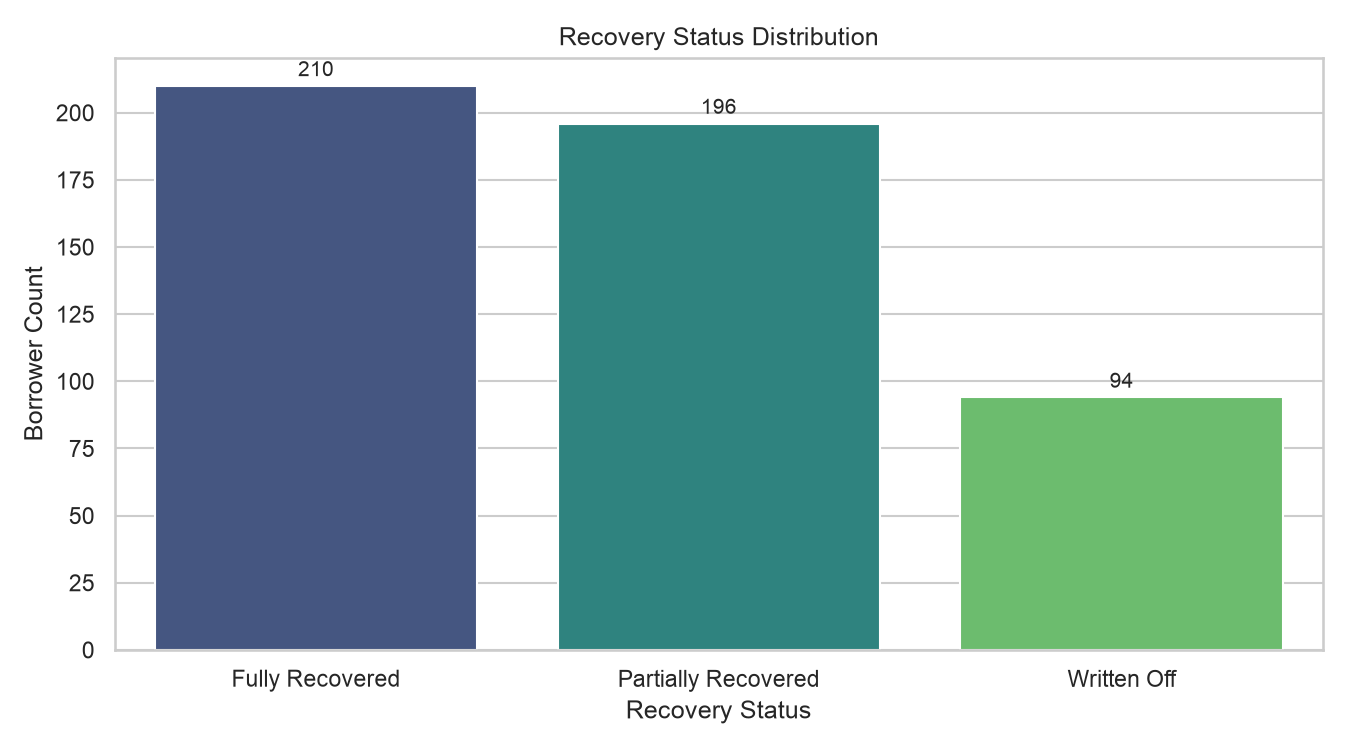

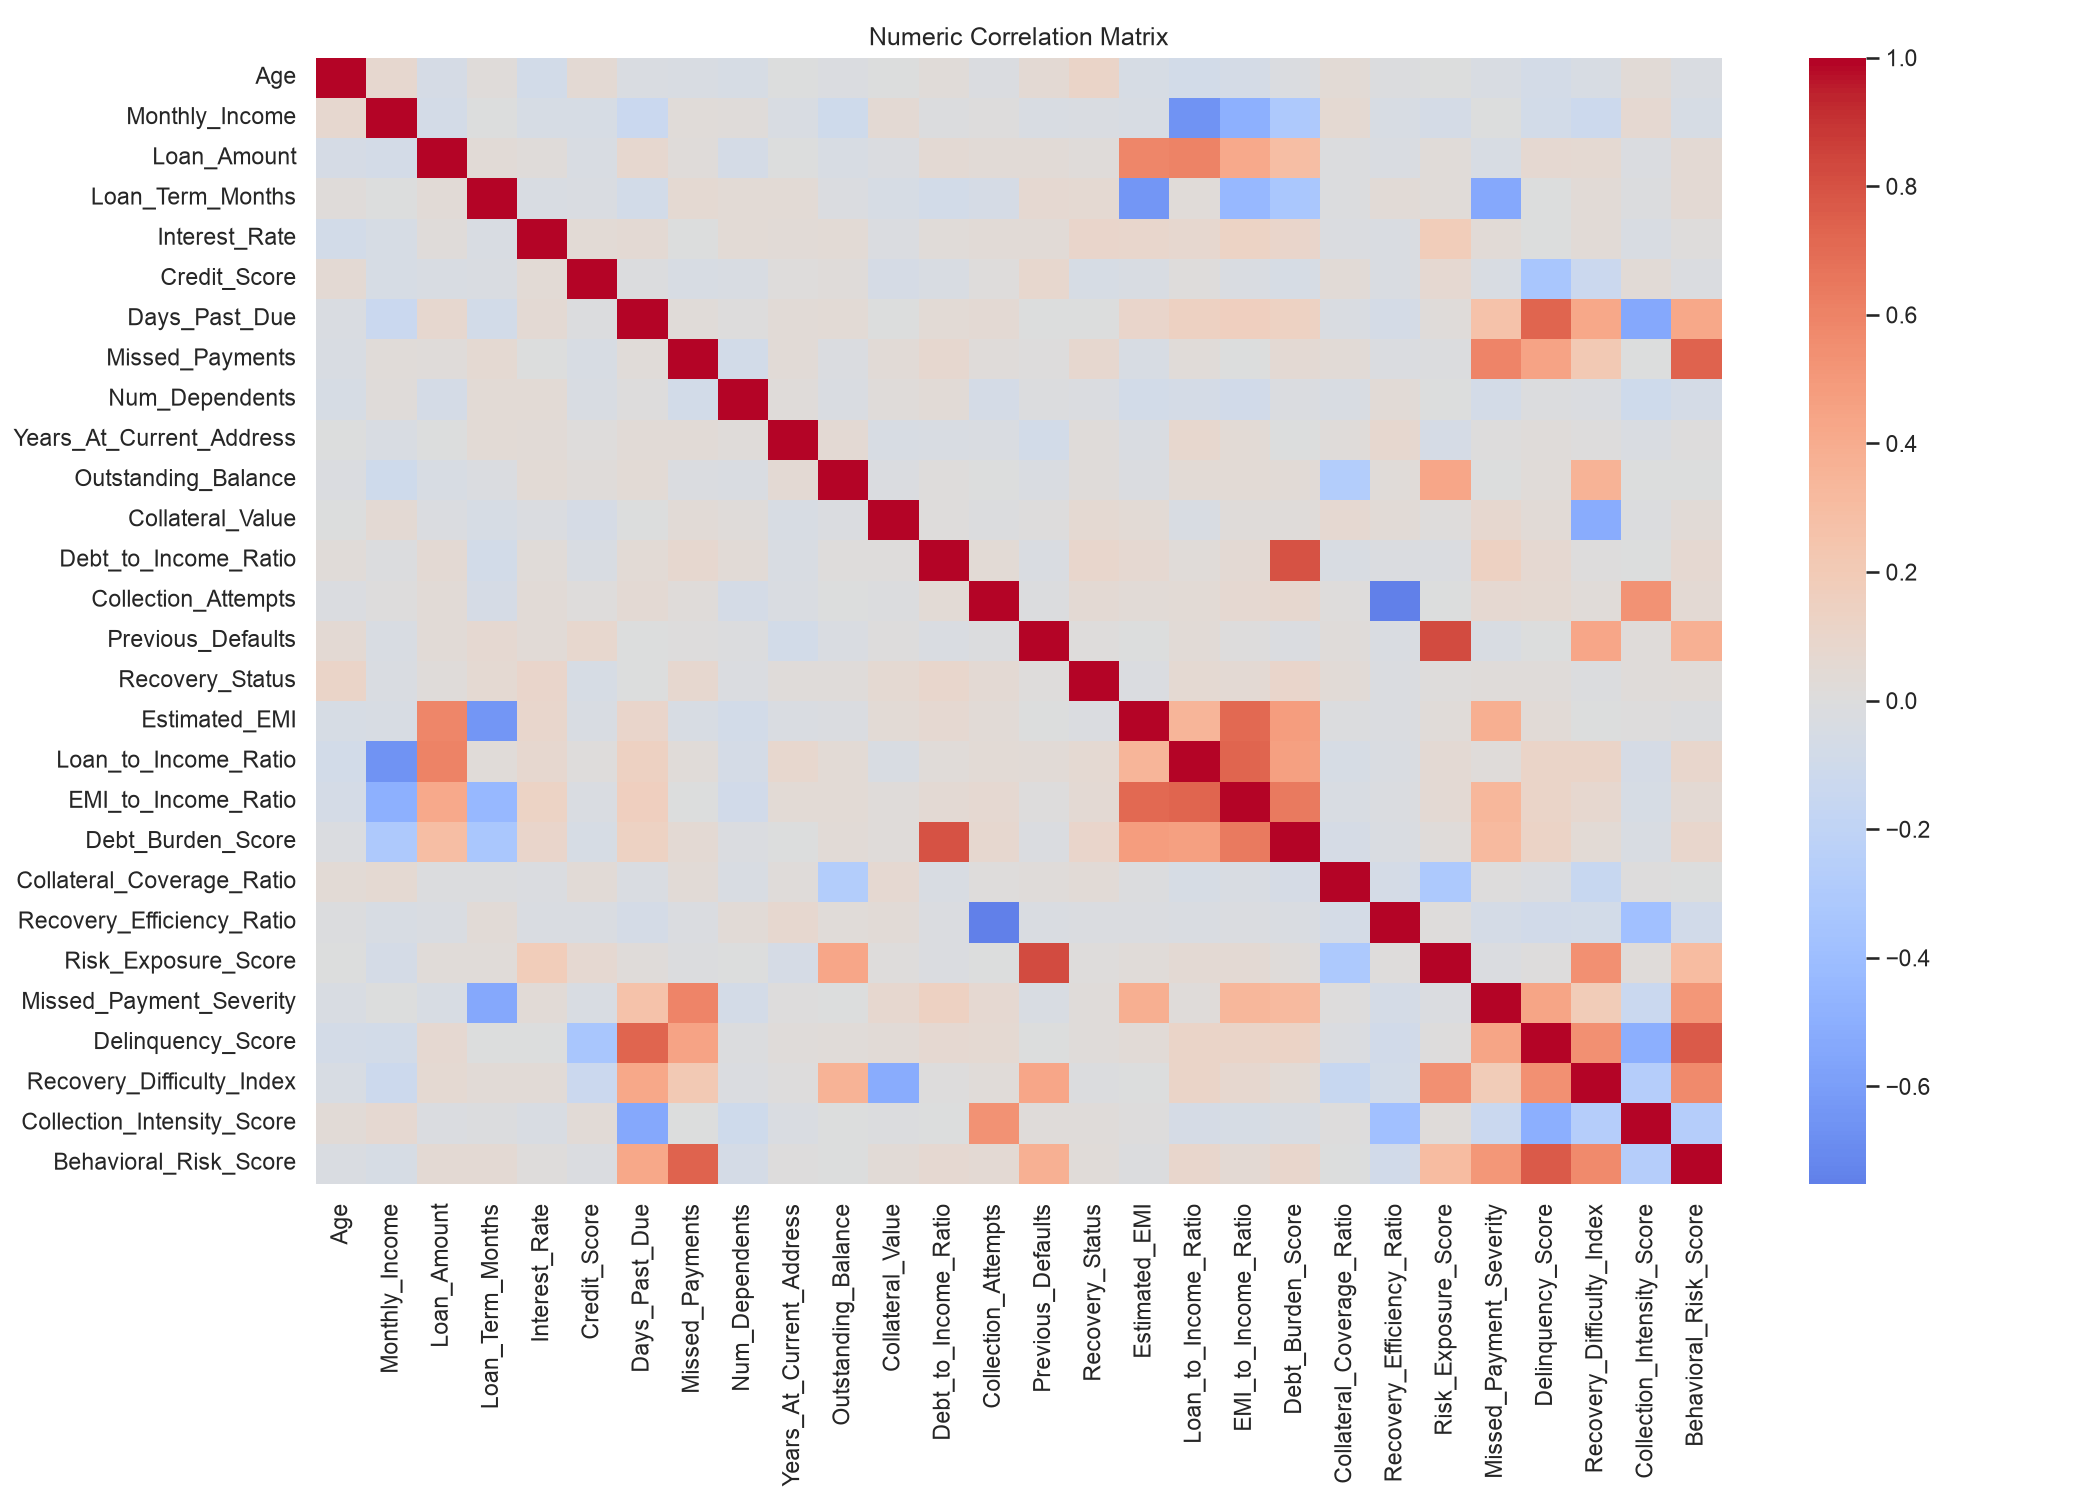

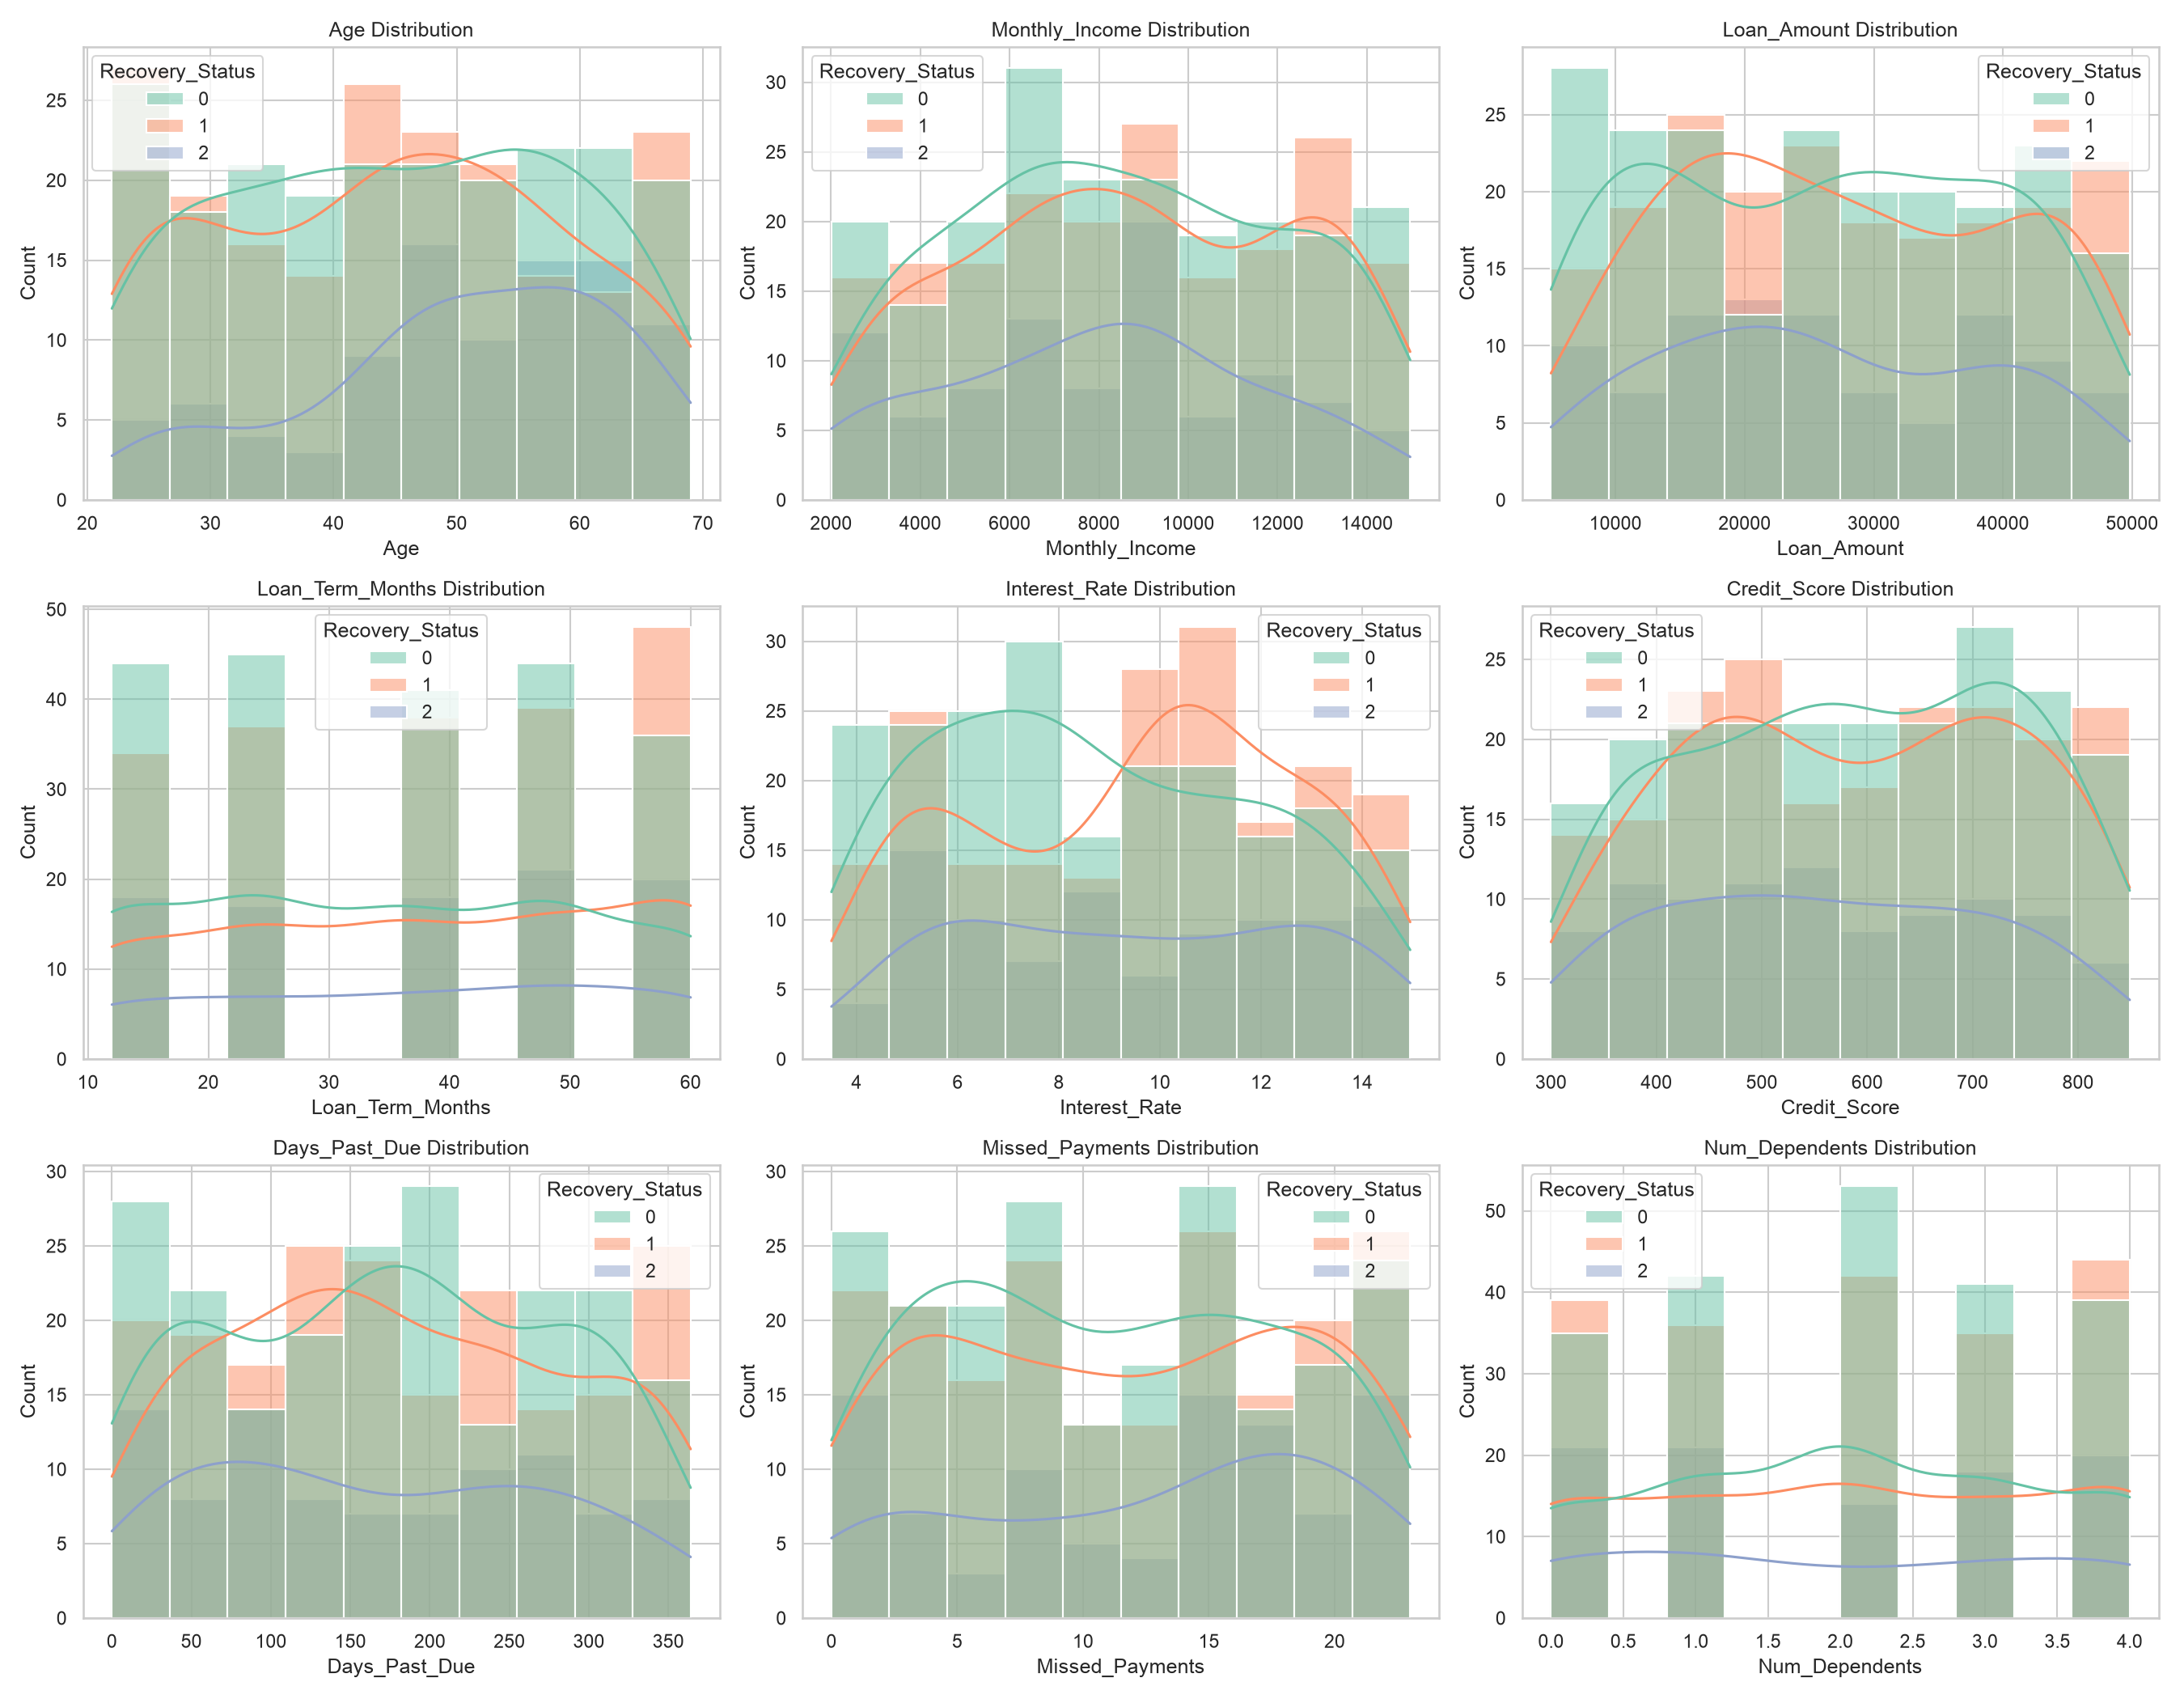

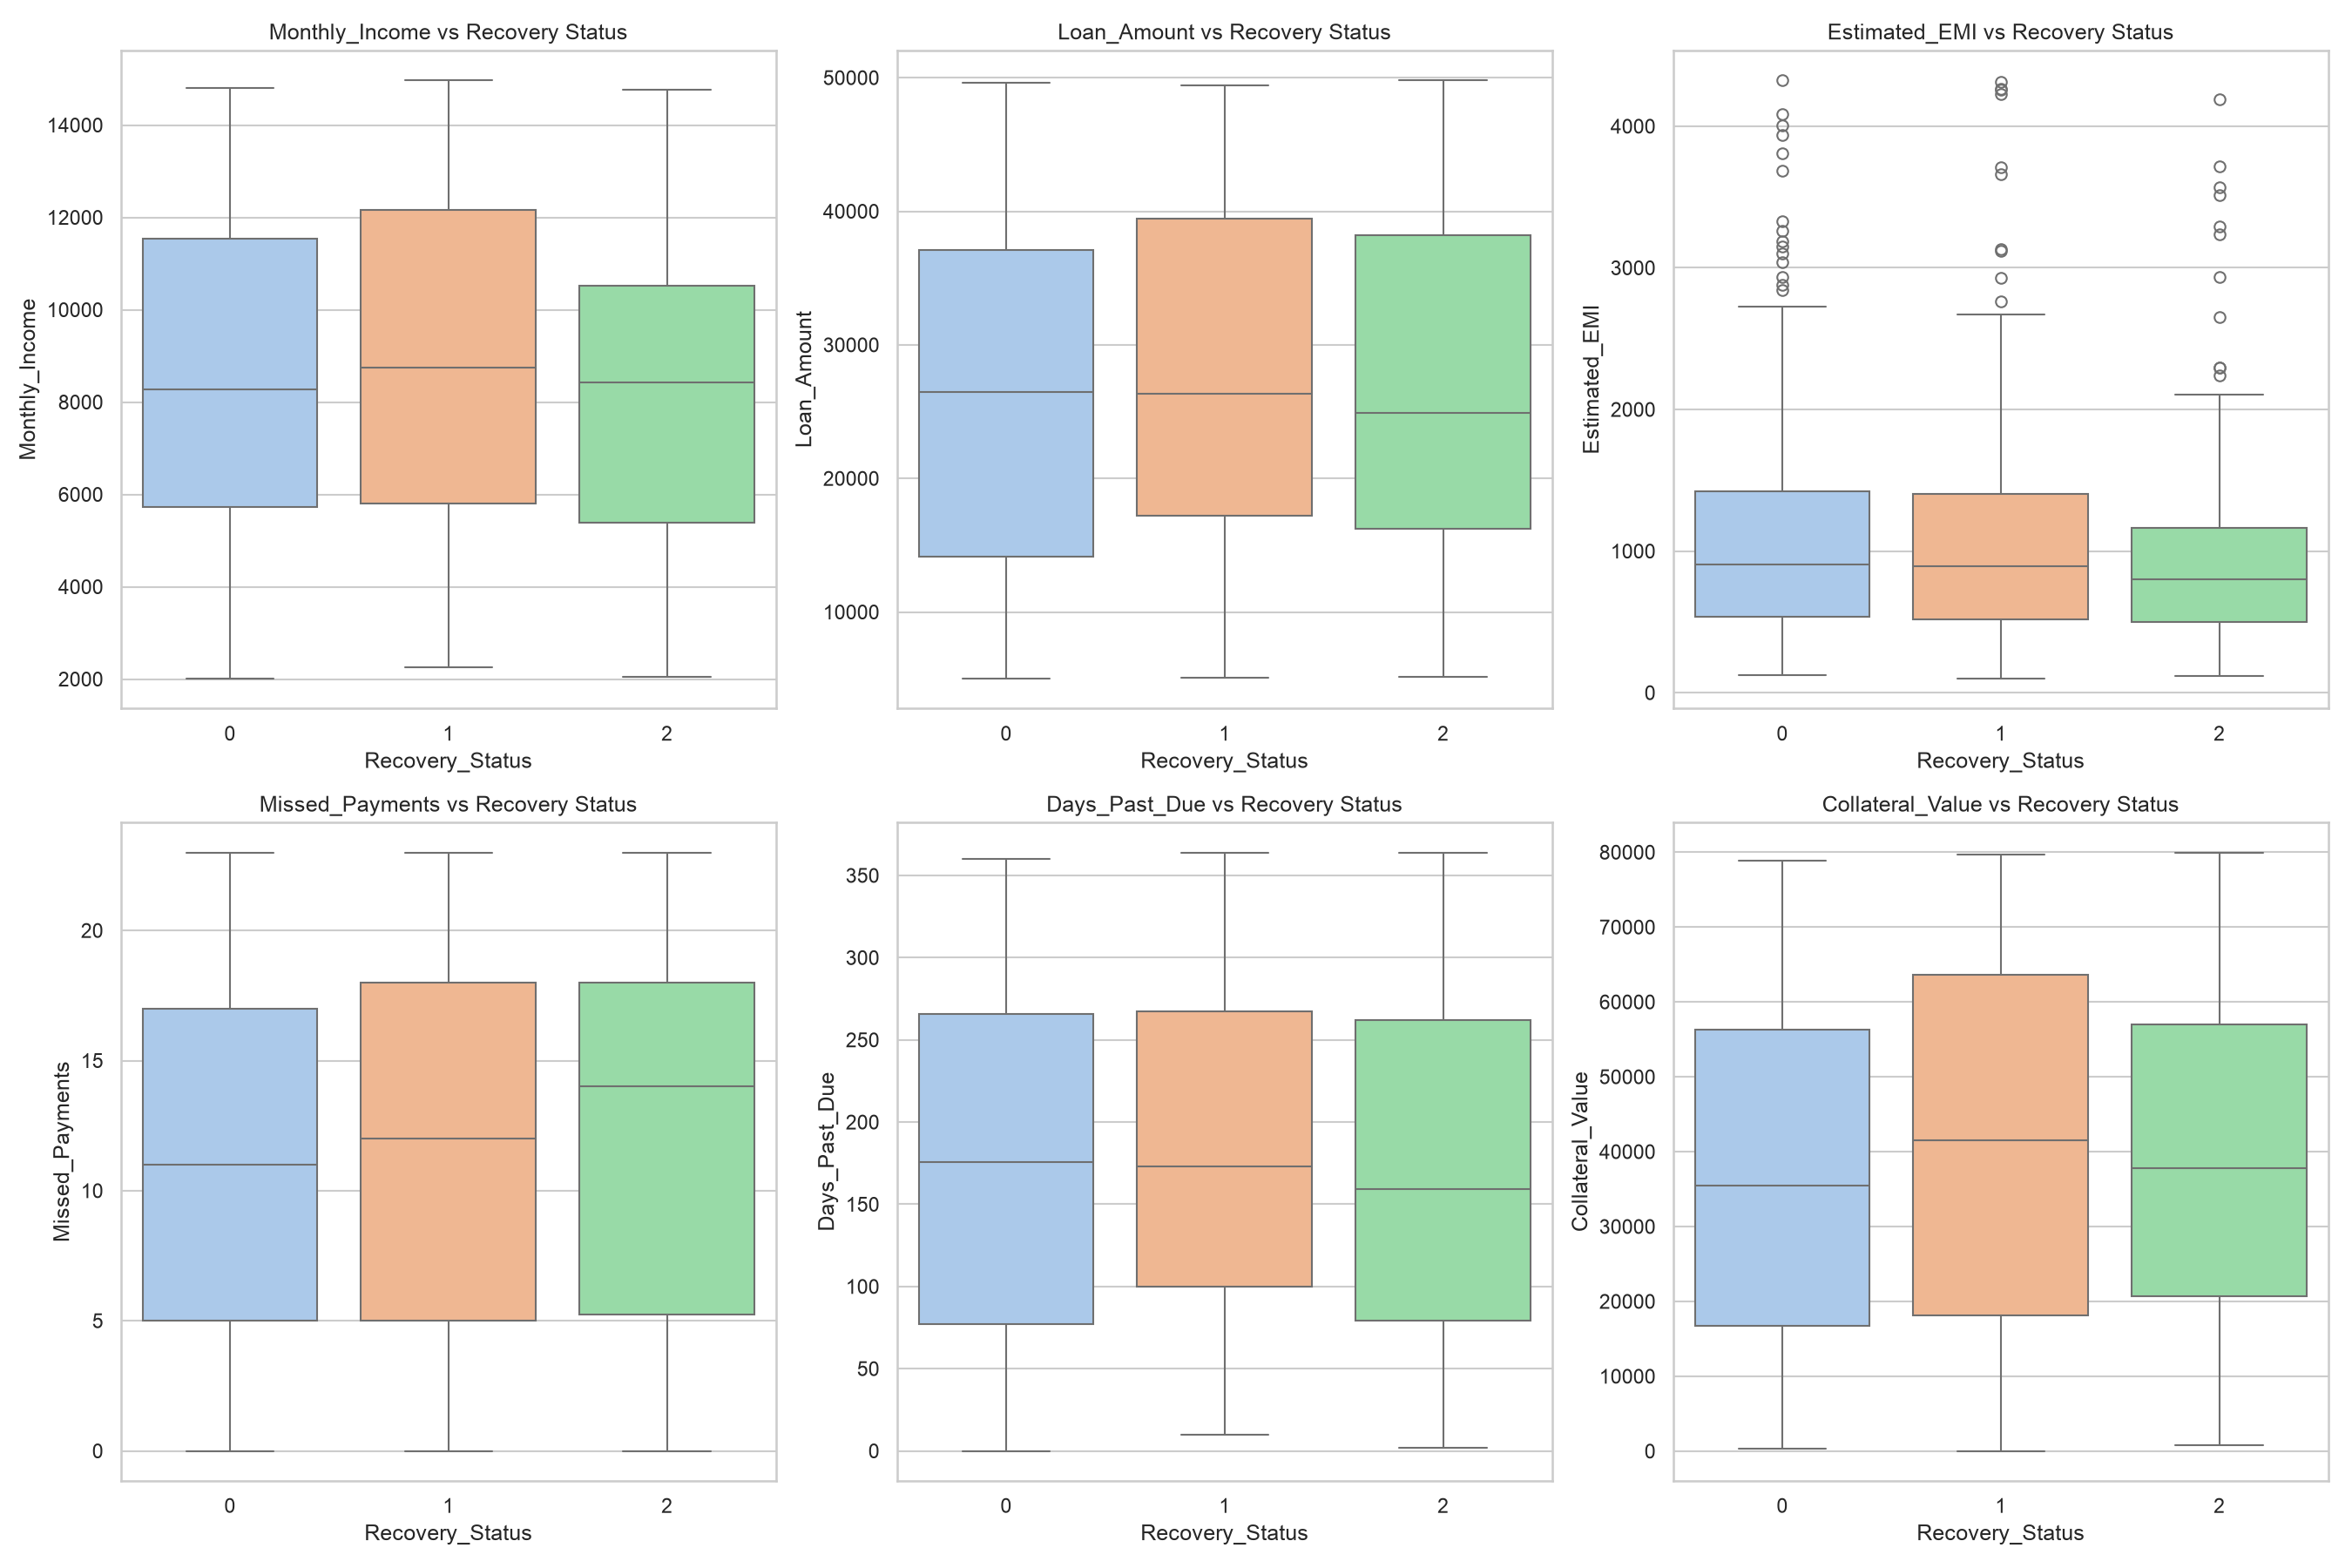

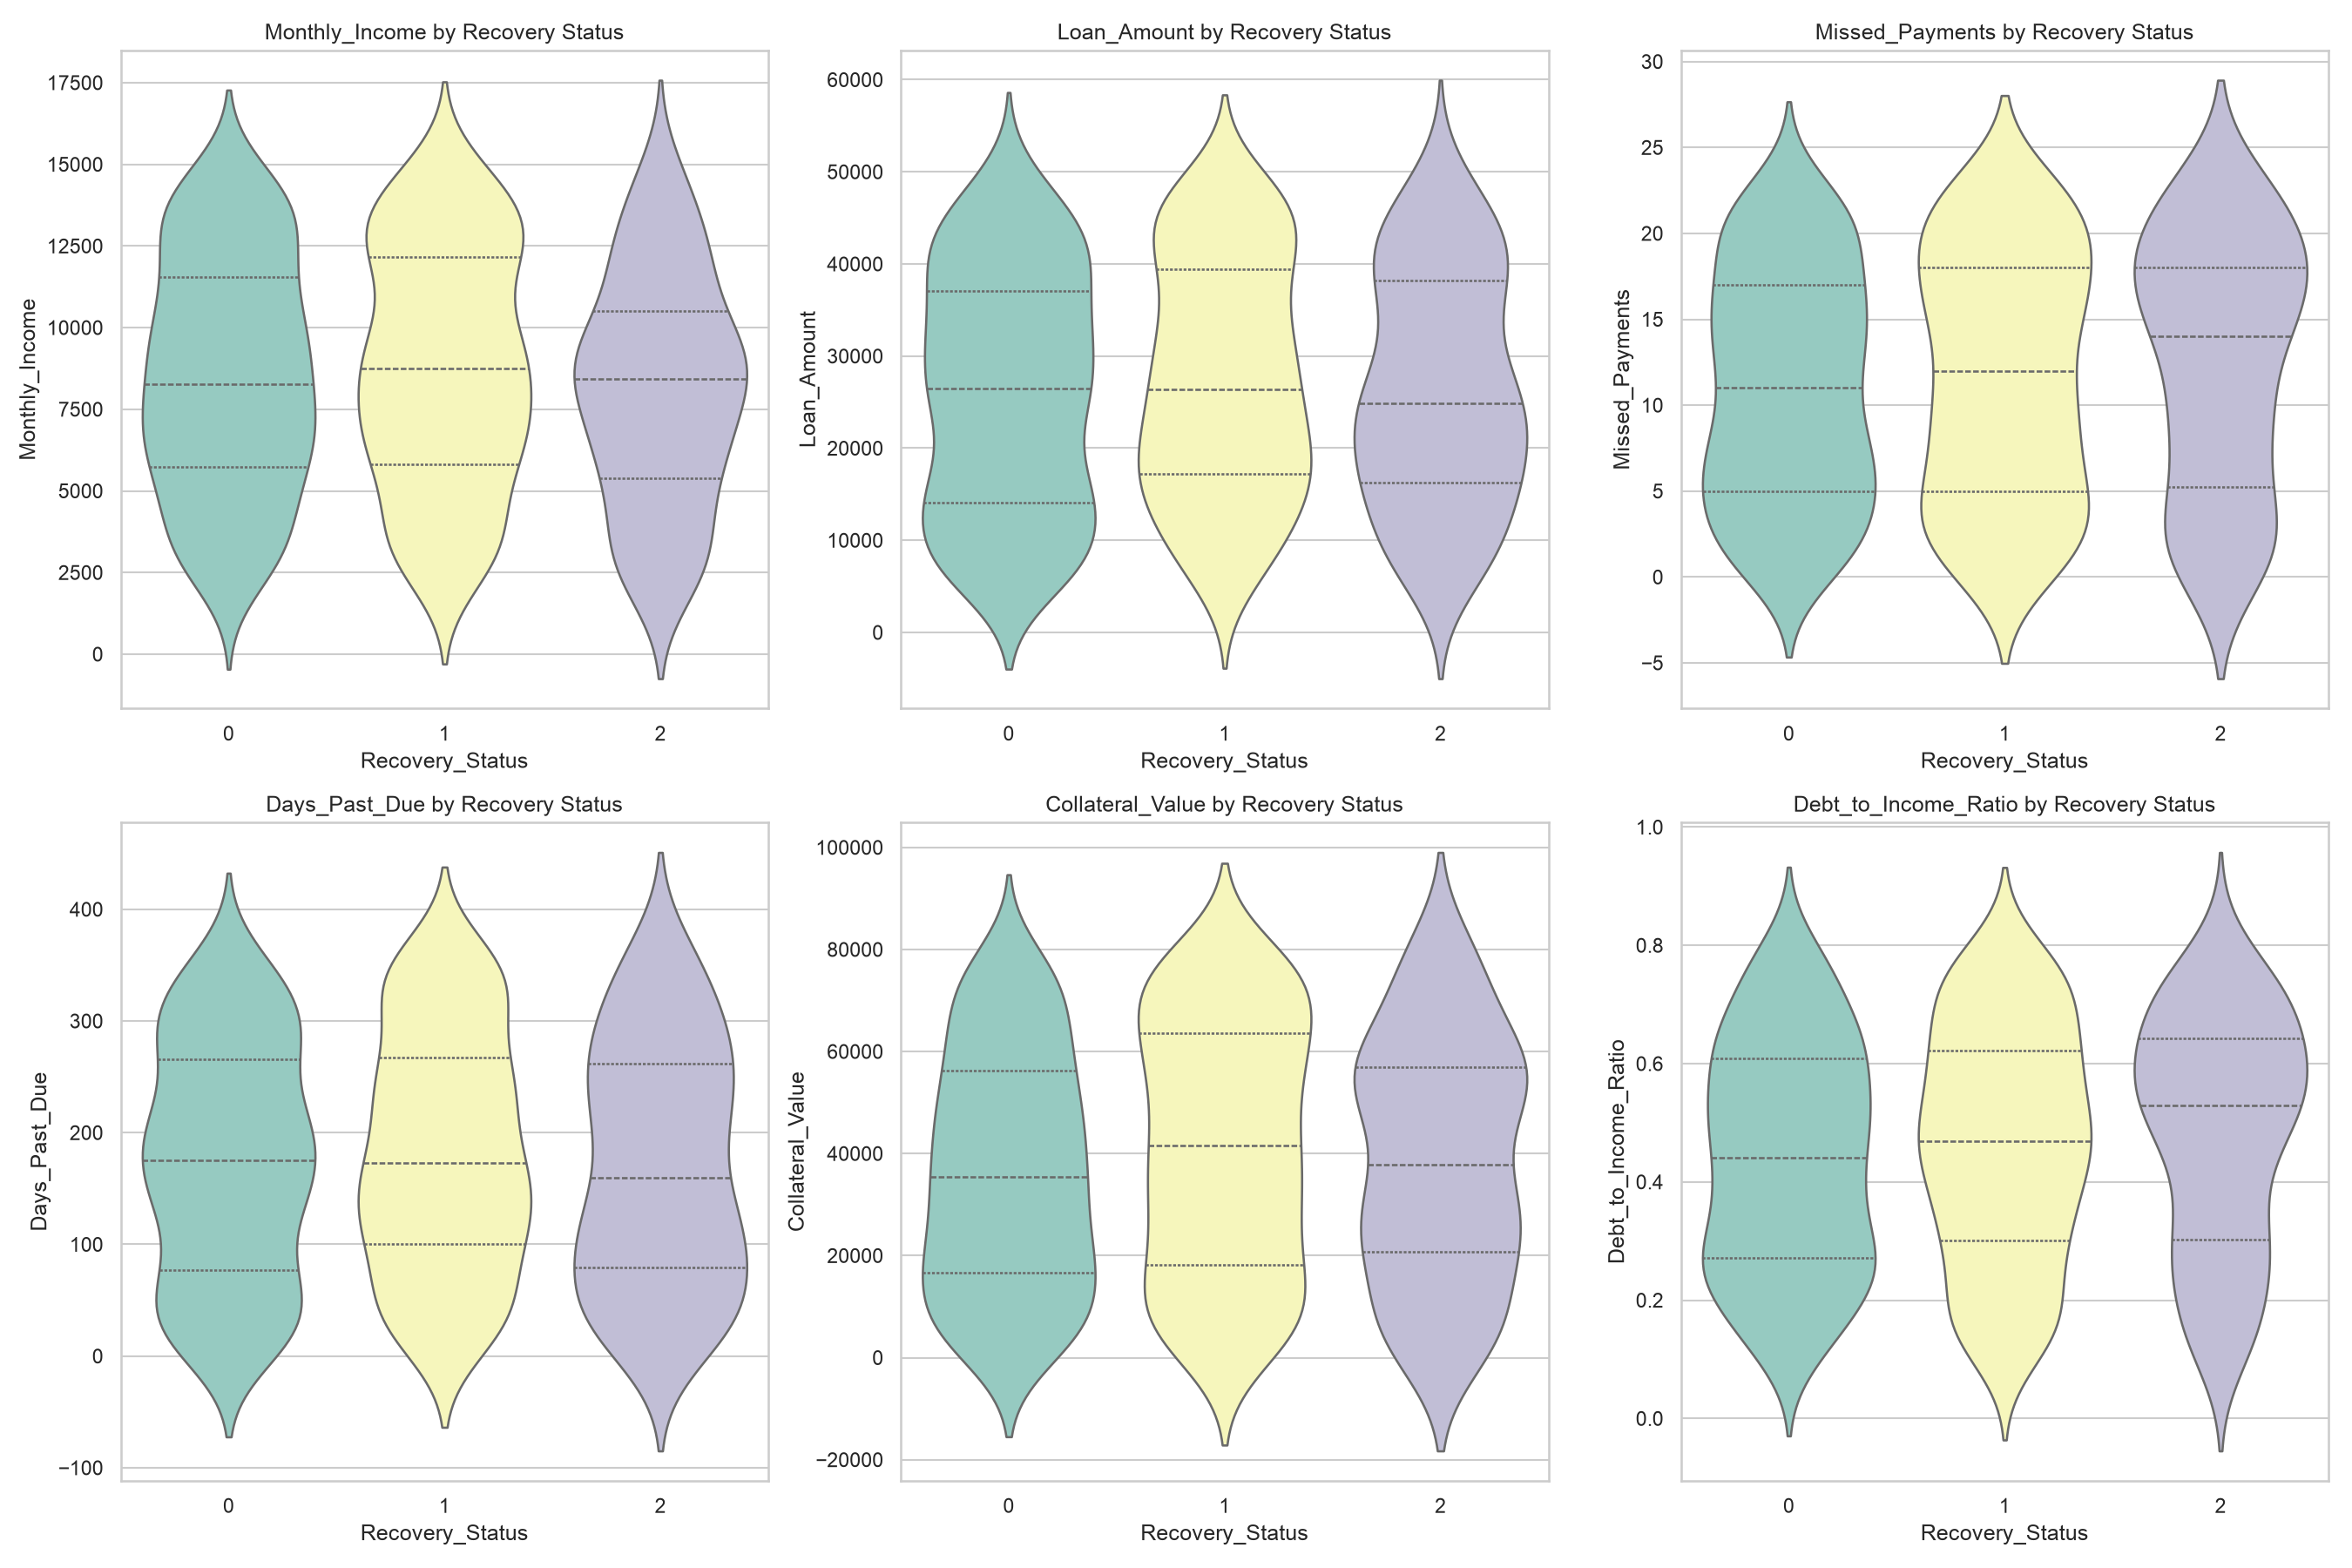

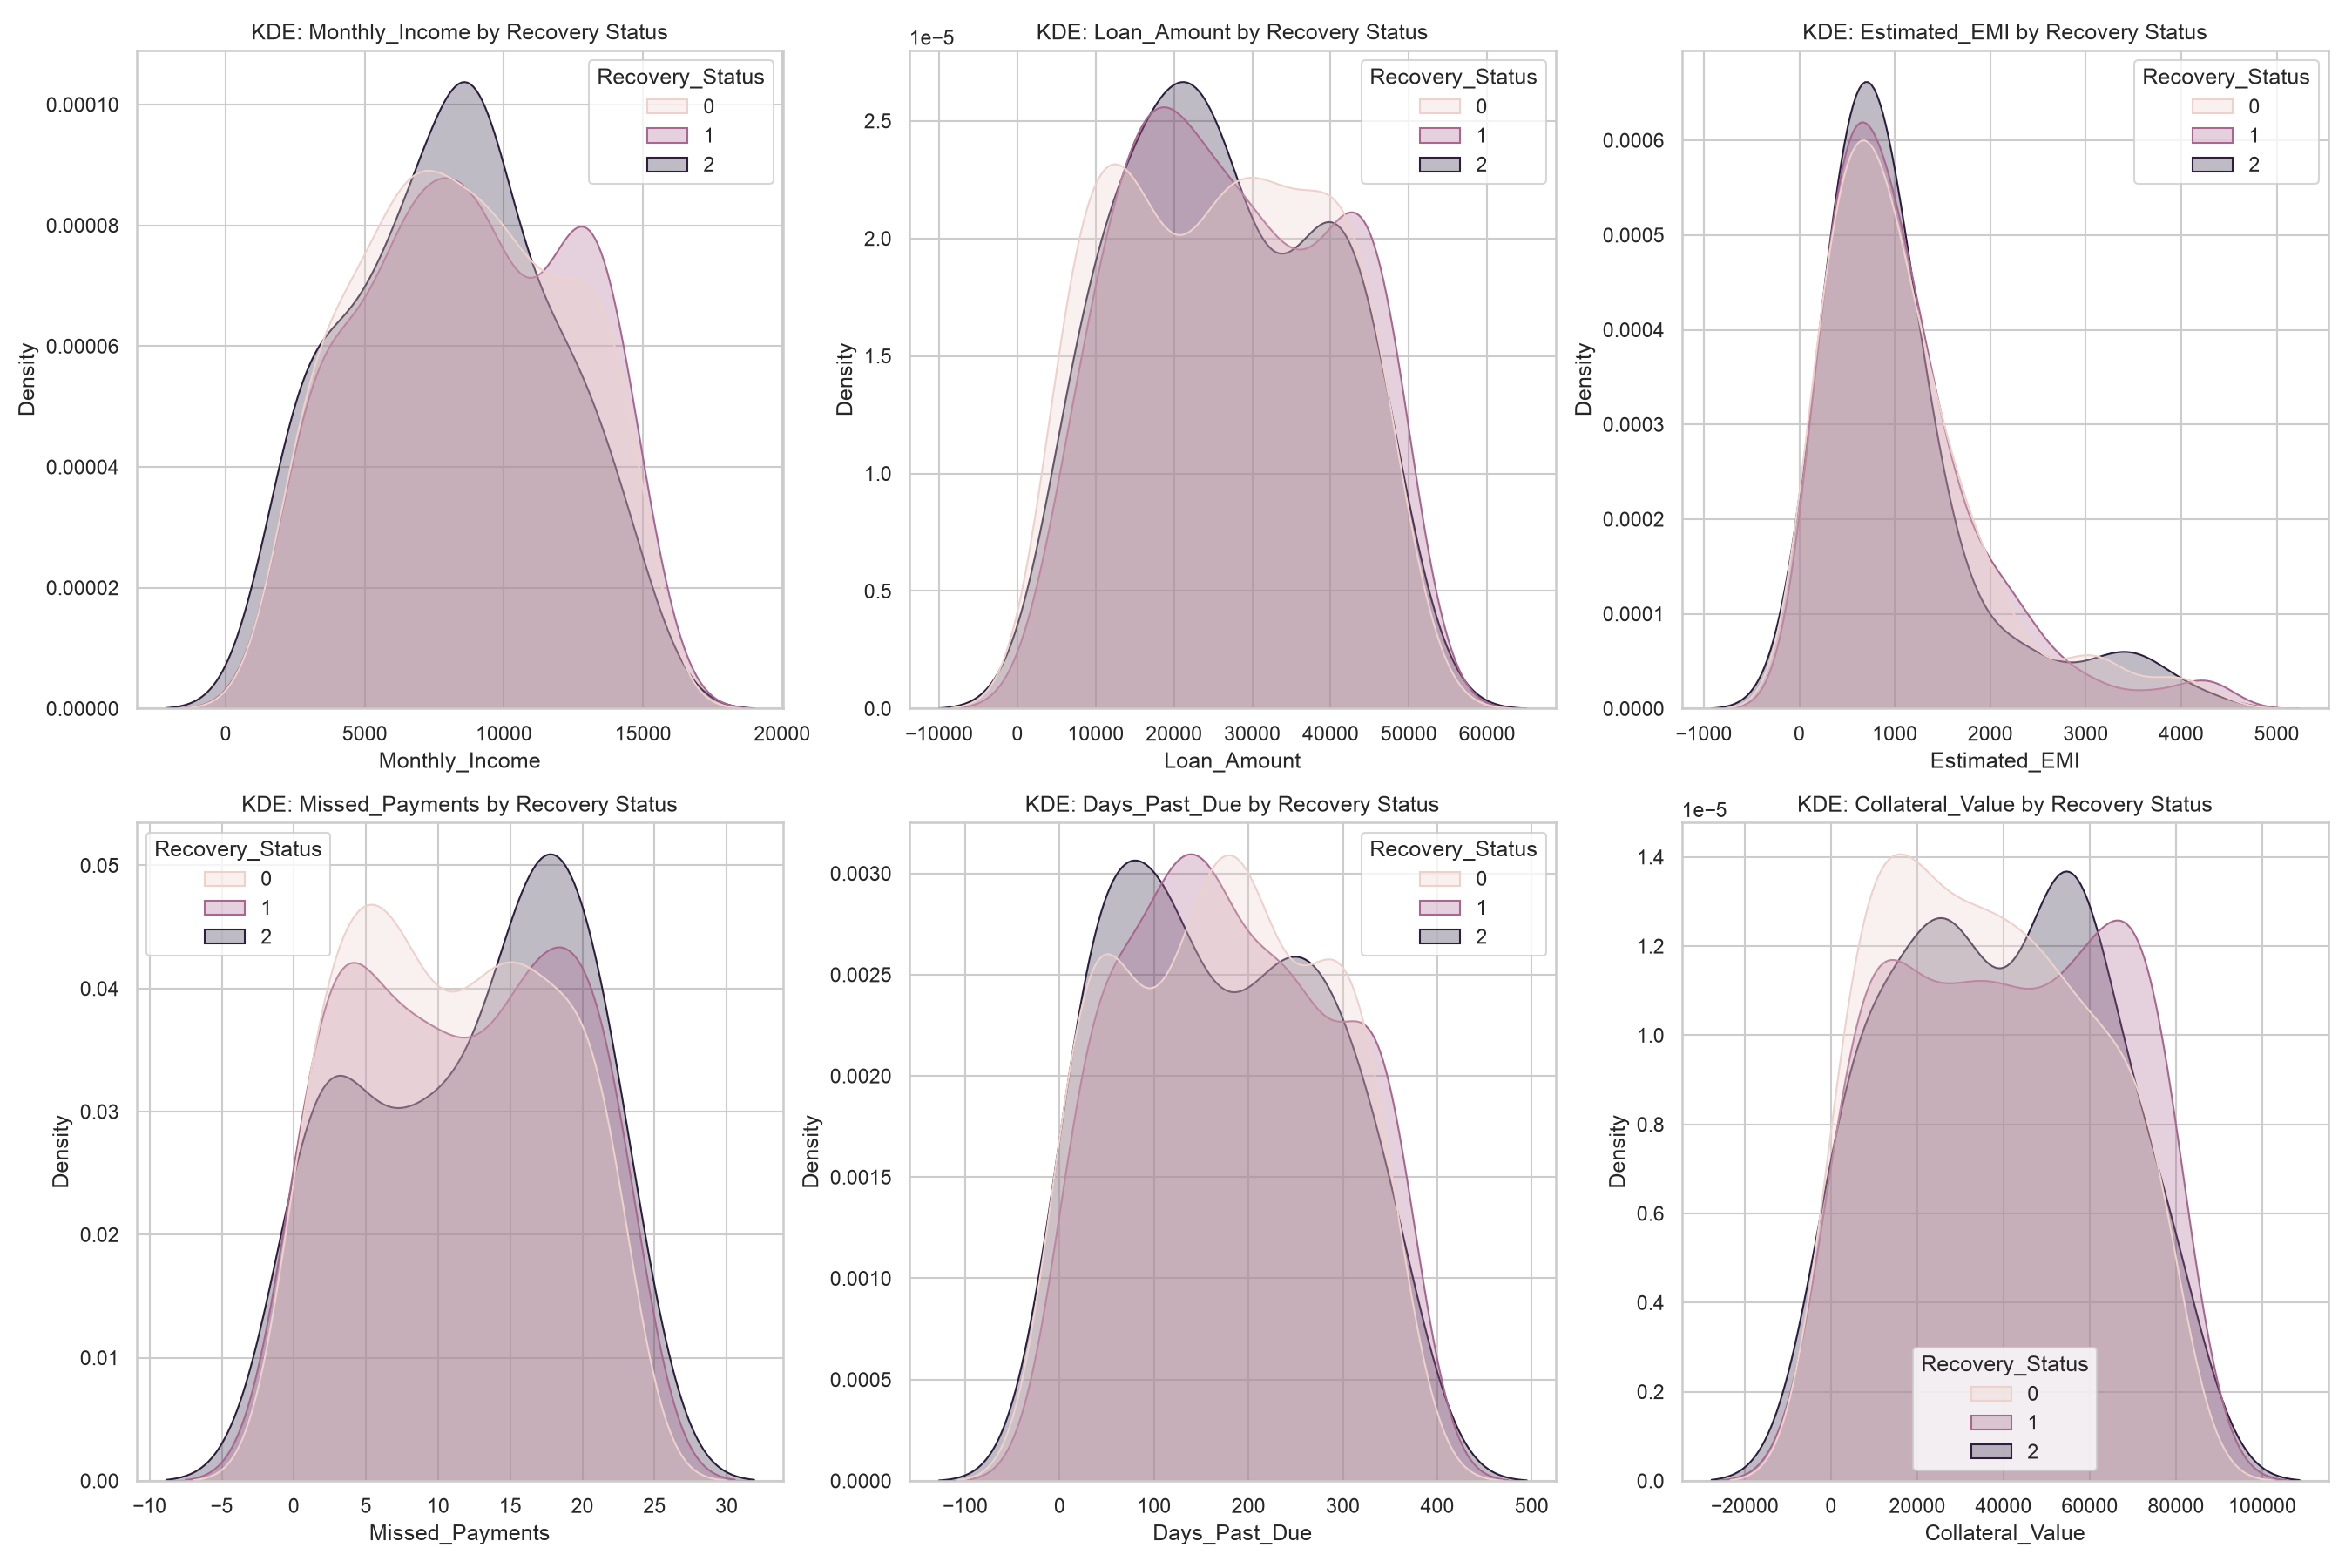

In [6]:
from IPython.display import Image, display

for image_path in [
    outputs.target_distribution,
    outputs.correlation_heatmap,
    outputs.numeric_histograms,
    outputs.boxplots,
    outputs.violin_plots,
    outputs.relationship_grid,
]:
    display(Image(filename=str(image_path)))


## Interpretation
- Higher `Days_Past_Due` and `Missed_Payments` often align with weaker recovery states.
- Borrowers with stronger collateral coverage generally look easier to recover.
- Income, debt burden, and repayment behavior jointly shape collection strategy decisions.
